In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns 

# Load the dataset
data = pd.read_csv('insurance - insurance.csv')

print(" First 10 rows of the dataset:")
print(data.head(10))

print("\n Shape of the dataset:")
print(data.shape)


 First 10 rows of the dataset:
   age     sex   bmi  children smoker     region  expenses
0   19  female  27.9         0    yes  southwest  16884.92
1   18    male  33.8         1     no  southeast   1725.55
2   28    male  33.0         3     no  southeast   4449.46
3   33    male  22.7         0     no  northwest  21984.47
4   32    male  28.9         0     no  northwest   3866.86
5   31  female  25.7         0     no  southeast   3756.62
6   46  female  33.4         1     no  southeast   8240.59
7   37  female  27.7         3     no  northwest   7281.51
8   37    male  29.8         2     no  northeast   6406.41
9   60  female  25.8         0     no  northwest  28923.14

 Shape of the dataset:
(1338, 7)


In [2]:
print("Missing values in the dataset:")
print(data.isnull().sum())

duplicate_rows = data.duplicated().sum()
print(f"\nNumber of duplicate rows in the dataset: {duplicate_rows}")
data = data.drop_duplicates()

# We find the duplicate rows in the dataset and remove them to ensure data integrity.
# This step is crucial for accurate analysis and modeling.
# we remove them with the drop_duplicates() function, which eliminates any duplicate entries based on all columns.

Missing values in the dataset:
age         0
sex         0
bmi         0
children    0
smoker      0
region      0
expenses    0
dtype: int64

Number of duplicate rows in the dataset: 1


In [6]:
print("Stastistical summary of the dataset:")
print(data.describe())

print("Age column:")
print("Maximum Value of age:",data["age"].max())
print("Minimum Value of age:",data["age"].min())
print("Average Value of age:",data["age"].mean())
print("median Value of age:",data["age"].median())
print("\n Expenses column:")
print("Maximum value of expenses:",data["expenses"].max())
print("Minimum value of expenses:",data["expenses"].min())
print("Average value of expenses:",data["expenses"].mean())
print("median value of expenses:",data["expenses"].median())

print("\n BMI column:")
print("Maximum value of bmi:",data["bmi"].max())
print("Minimum value of bmi:",data["bmi"].min())
print("Average value of bmi:",data["bmi"].mean())
print("median value of bmi:",data["bmi"].median())

Stastistical summary of the dataset:
               age          bmi     children      expenses
count  1337.000000  1337.000000  1337.000000   1337.000000
mean     39.222139    30.665520     1.095737  13279.121638
std      14.044333     6.100664     1.205571  12110.359657
min      18.000000    16.000000     0.000000   1121.870000
25%      27.000000    26.300000     0.000000   4746.340000
50%      39.000000    30.400000     1.000000   9386.160000
75%      51.000000    34.700000     2.000000  16657.720000
max      64.000000    53.100000     5.000000  63770.430000
Age column:
Maximum Value of age: 64
Minimum Value of age: 18
Average Value of age: 39.222139117427076
median Value of age: 39.0

 Expenses column:
Maximum value of expenses: 63770.43
Minimum value of expenses: 1121.87
Average value of expenses: 13279.121637995511
median value of expenses: 9386.16

 BMI column:
Maximum value of bmi: 53.1
Minimum value of bmi: 16.0
Average value of bmi: 30.665519820493646
median value of bmi: 30.

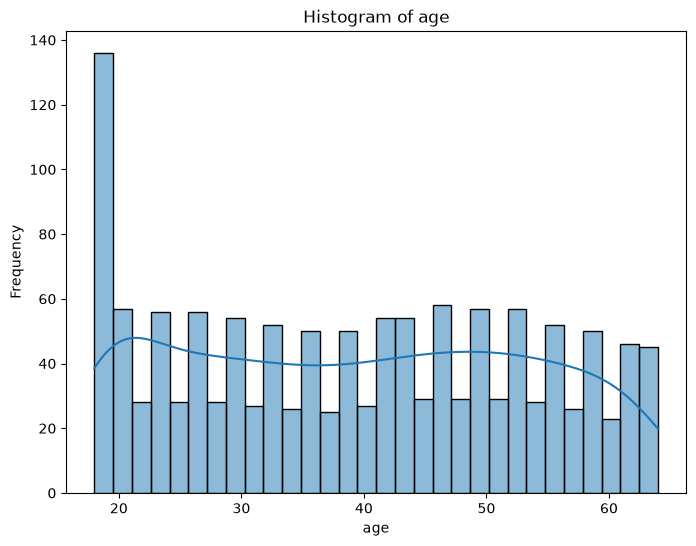

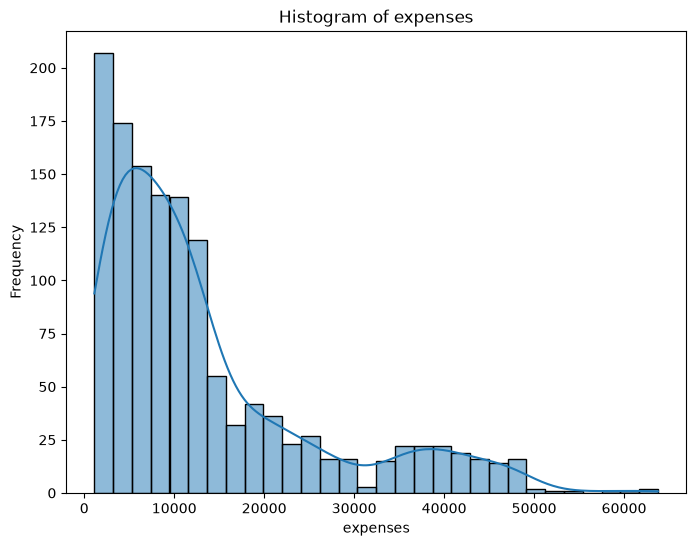

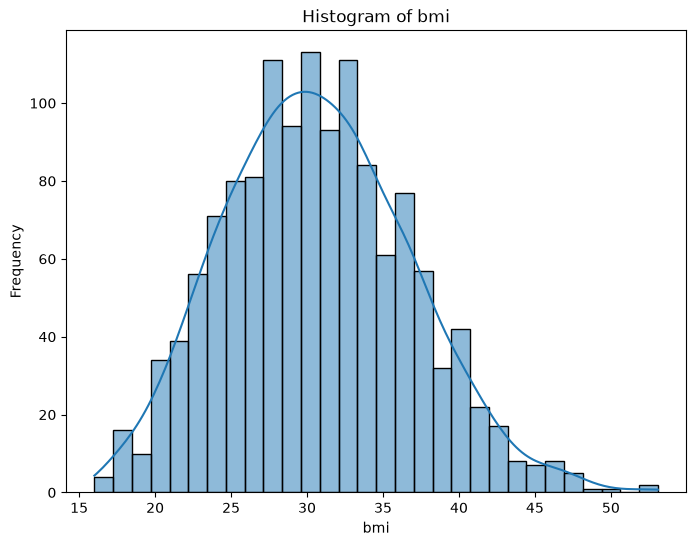

In [8]:
def plot_histograms(data):
    columns = ['age', 'expenses', 'bmi']
    for column in columns:
        plt.figure(figsize=(8, 6))
        sns.histplot(data[column], bins=30, kde=True)
        plt.title(f'Histogram of {column}')
        plt.xlabel(column)
        plt.ylabel('Frequency')
        plt.show() 
plot_histograms(data) 

# Findings:

# 1. The dataset contains information about individuals, including their age, expenses, and BMI (Body Mass Index).
# 2. The age column has a maximum value of 64, a minimum value of 18, an average value of approximately 39.21, and a median value of 39.0.
# 3. The expenses column has a maximum value of 63770.43, a minimum value of 1121.87, an average value of approximately 13270.42, and a median value of 9382.03.
# 4. The BMI column has a maximum value of 53.13, a minimum value of 15.96, an average value of approximately 30.66, and a median value of 30.4.

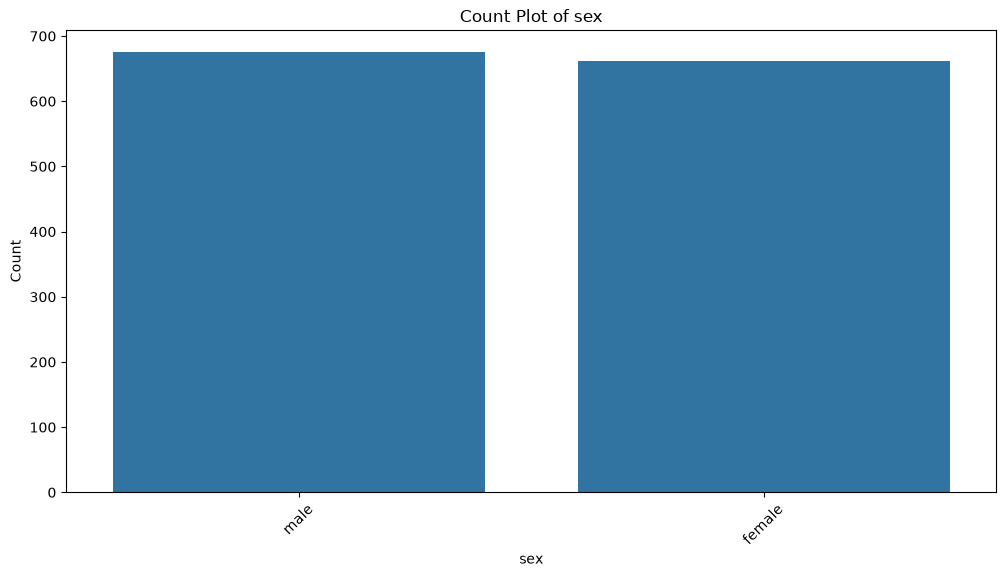

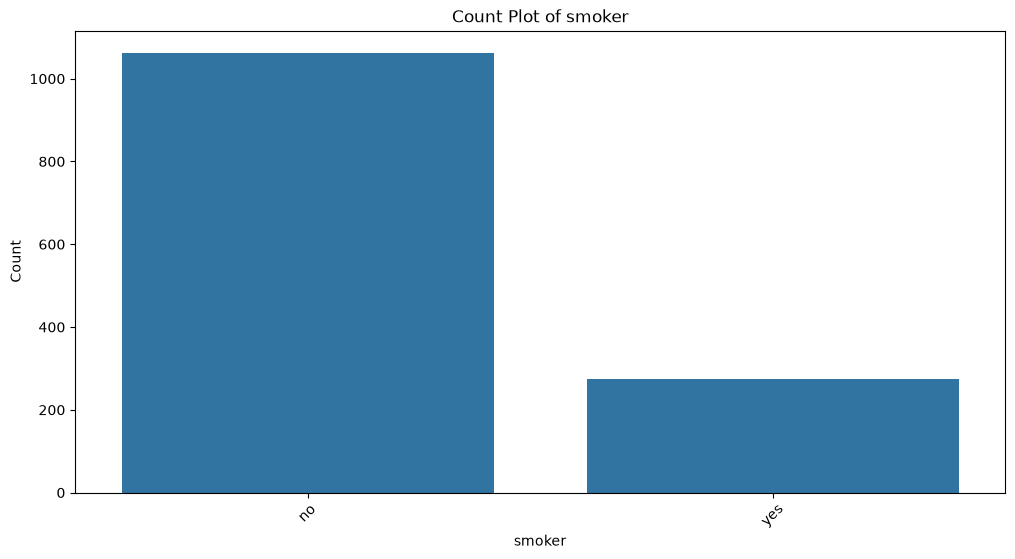

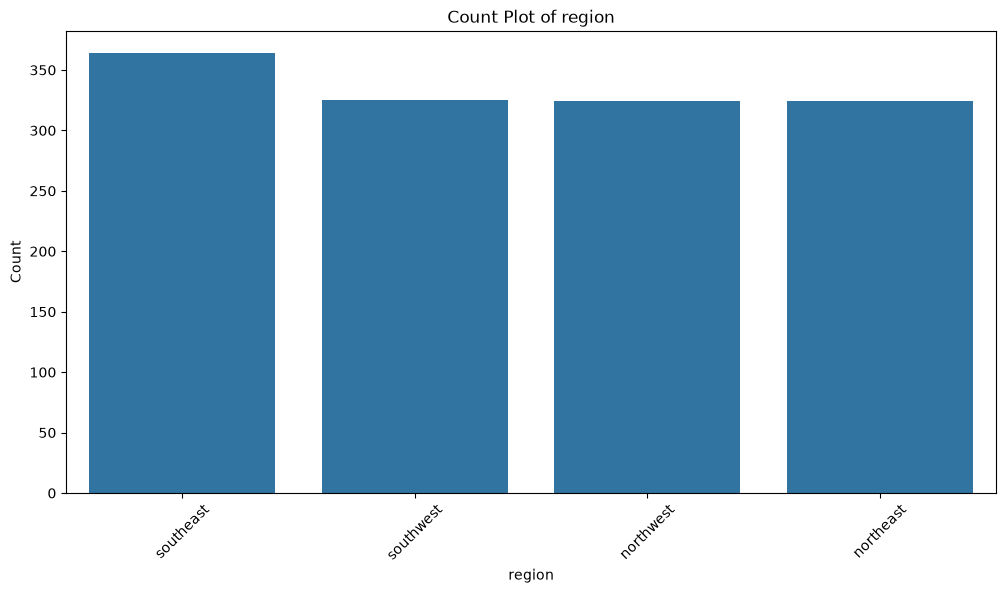

In [11]:
def plot_countplots(data):
    columns = ['sex', 'smoker', 'region']
    for column in columns:
        plt.figure(figsize=(12, 6))
        sns.countplot(data=data, x=column, order=data[column].value_counts().index)
        plt.title(f'Count Plot of {column}')
        plt.xlabel(column)
        plt.ylabel('Count')
        plt.xticks(rotation=45)
        plt.show()
plot_countplots(data)

# Findings:

# 1. The dataset contains categorical variables such as sex, smoker status, and region.
# 2. The count plots show the distribution of these categorical variables.
# 3. The sex column has a relatively balanced distribution between male and female participants.
# 4. The smoker column shows that the majority of individuals in the dataset are non-smokers.
# 5. The region column indicates that the dataset includes individuals from different regions, with some regions having higher representation than others.  

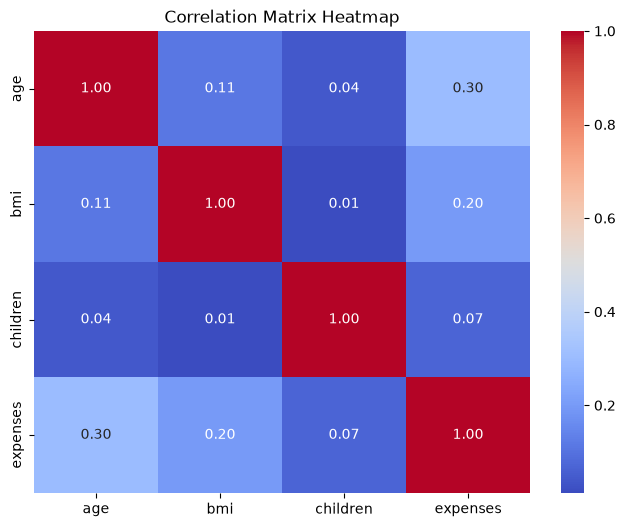

Correlation with Expenses:
expenses    1.000000
age         0.298308
bmi         0.198637
children    0.067389
Name: expenses, dtype: float64


In [14]:
# Select only numeric columns
numeric_data = data.select_dtypes(include=['int64', 'float64'])

# Create correlation matrix
corr_matrix = numeric_data.corr()

# Plot heatmap
plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f")

# Title
plt.title("Correlation Matrix Heatmap")

# Show plot
plt.show()

# Display correlation with expenses
print("Correlation with Expenses:")
print(corr_matrix["expenses"].sort_values(ascending=False))

# Observations:
# 1. The heatmap shows the correlation between numeric variables in the dataset.
# 2. The correlation matrix indicates that age has a positive correlation with expenses (0.30), meaning that as age increases, expenses tend to increase as well.
# 3. BMI has a positive correlation with expenses (0.20), suggesting that individuals with higher BMI tend to have higher expenses.
# 4. The correlation between age and BMI is relatively low (0.11), indicating that there is not a strong linear relationship between these two variables.


In [15]:
# Independent Features (X)
X = data[['age', 'sex', 'bmi', 'children', 'smoker', 'region']]

# Dependent Feature (y)
y = data['expenses']

# Reasoning:

# The independent features (X) are selected based on their potential influence on the dependent feature (y), which is the expenses. The selected features include
# - age: Age of the individual
# - sex: Gender of the individual
# - bmi: Body Mass Index of the individual
# - children: Number of children the individual has
# - smoker: Smoking status of the individual
# - region: Geographic region of the individual
# - These features are chosen because they are likely to have an impact on the expenses incurred by the individual, making them relevant for predictive modeling.  


In [16]:
print("Categorical Features Before Encoding:")
print(data[['sex', 'smoker', 'region']].head())

encoded_features = pd.get_dummies(data[['sex', 'smoker', 'region']])
print("\nCategorical Features After Encoding:")
print(encoded_features.head())

Categorical Features Before Encoding:
      sex smoker     region
0  female    yes  southwest
1    male     no  southeast
2    male     no  southeast
3    male     no  northwest
4    male     no  northwest

Categorical Features After Encoding:
   sex_female  sex_male  smoker_no  smoker_yes  region_northeast  \
0        True     False      False        True             False   
1       False      True       True       False             False   
2       False      True       True       False             False   
3       False      True       True       False             False   
4       False      True       True       False             False   

   region_northwest  region_southeast  region_southwest  
0             False             False              True  
1             False              True             False  
2             False              True             False  
3              True             False             False  
4              True             False             False  

In [19]:
from sklearn.preprocessing import StandardScaler
# Select numeric independent features
X = data[['age', 'bmi', 'children']]
# Create StandardScaler object
scaler = StandardScaler()

# Apply scaling
X_scaled = scaler.fit_transform(X)

# Convert scaled data into a DataFrame
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

# Display first 5 rows
print("First 5 rows of Scaled Data:")
print(X_scaled.head())


First 5 rows of Scaled Data:
        age       bmi  children
0 -1.440418 -0.453484 -0.909234
1 -1.511647  0.513986 -0.079442
2 -0.799350  0.382803  1.580143
3 -0.443201 -1.306169 -0.909234
4 -0.514431 -0.289506 -0.909234


   age     sex   bmi  children smoker     region  expenses
0   19  female  27.9         0    yes  southwest  16884.92
1   18    male  33.8         1     no  southeast   1725.55
2   28    male  33.0         3     no  southeast   4449.46
3   33    male  22.7         0     no  northwest  21984.47
4   32    male  28.9         0     no  northwest   3866.86

Missing Values:
age         0
sex         0
bmi         0
children    0
smoker      0
region      0
expenses    0
dtype: int64

Duplicate Rows: 0


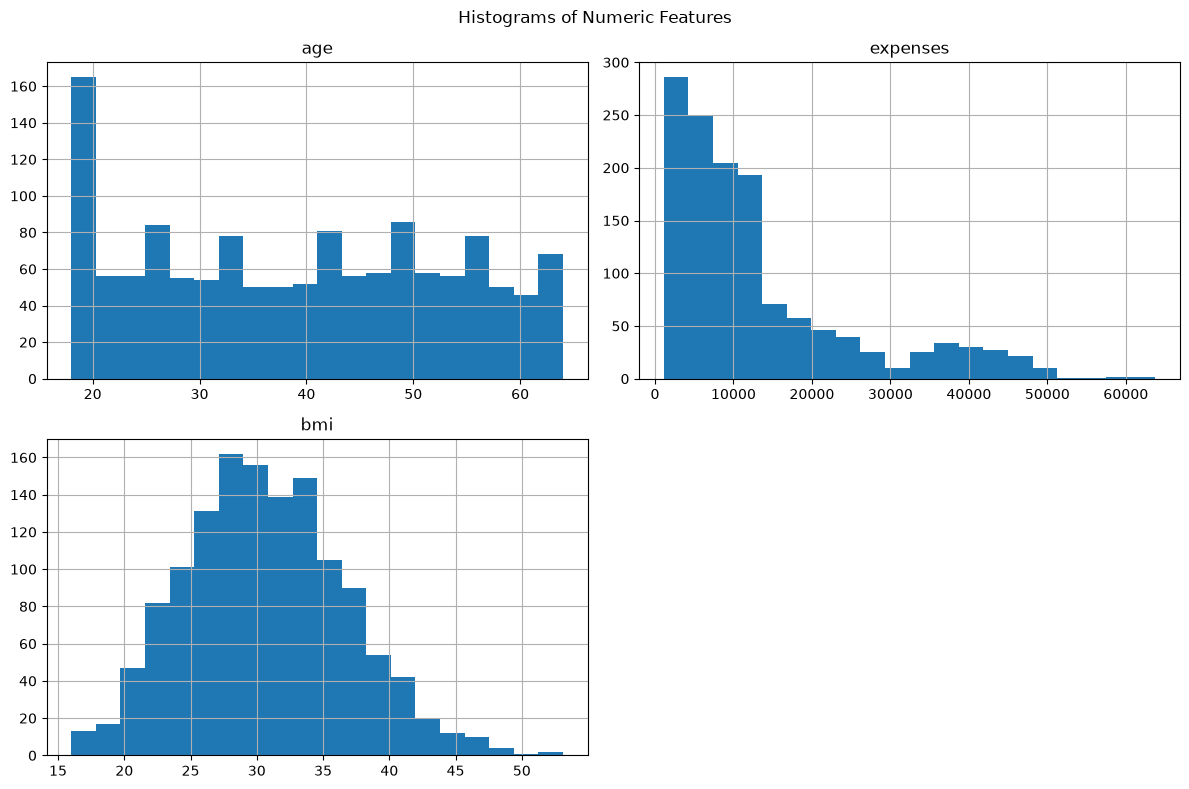

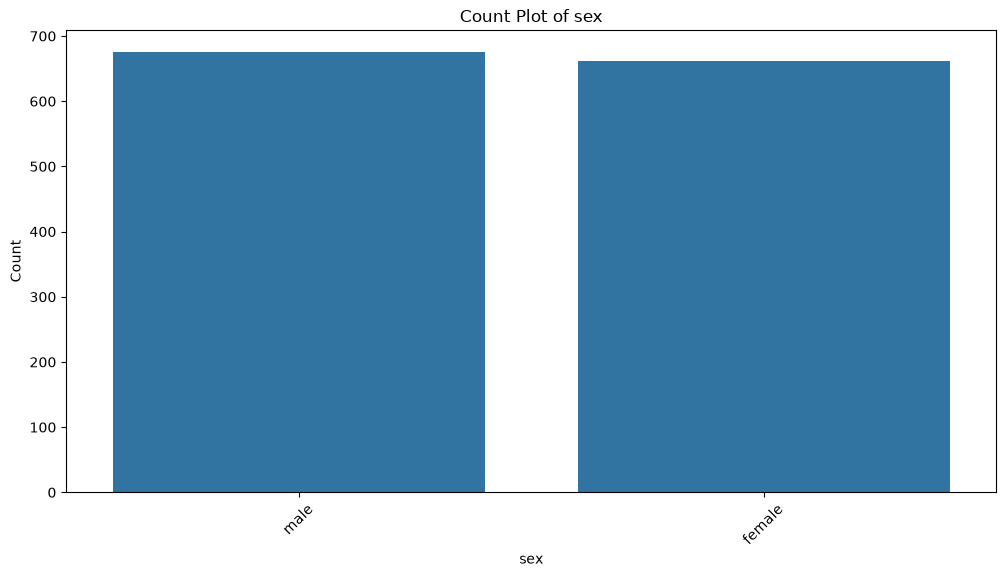

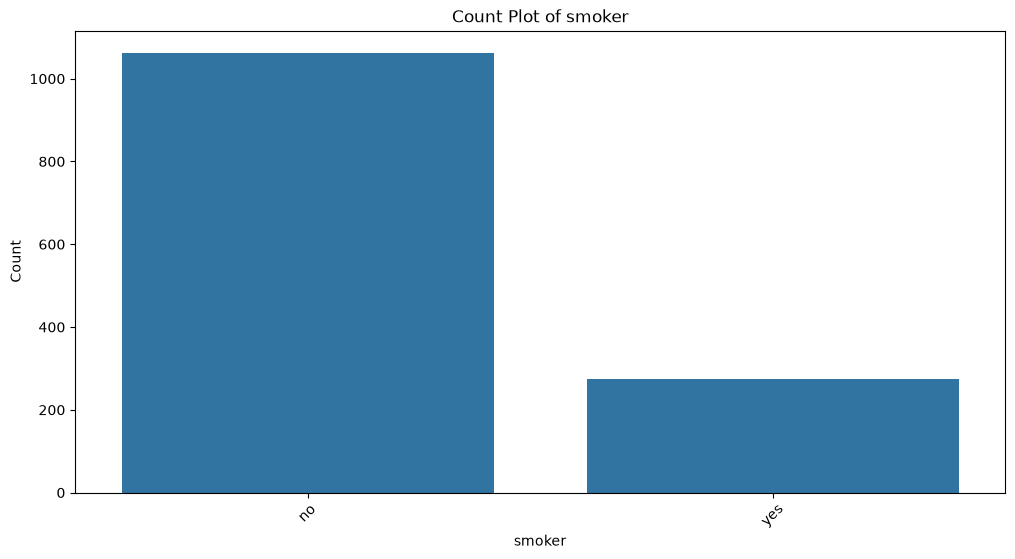

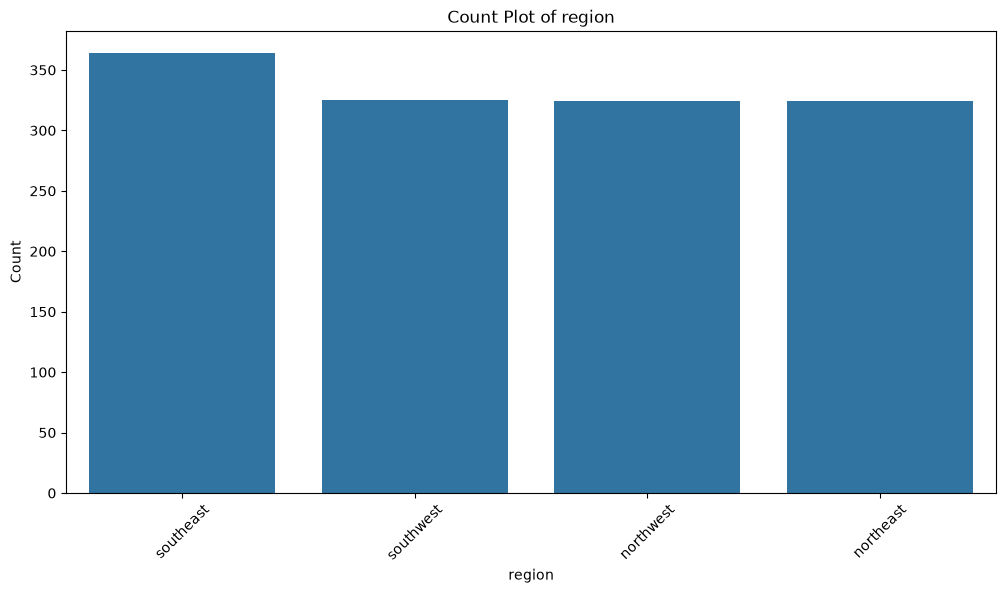

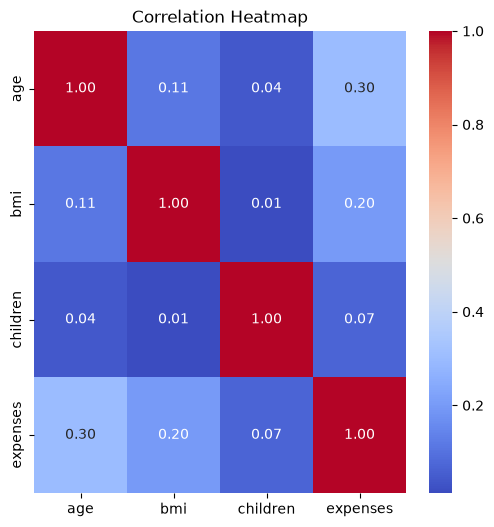


Independent Features:
Index(['age', 'sex', 'bmi', 'children', 'smoker', 'region'], dtype='str')

Dependent Feature:
expenses

Encoded Data:
   age   bmi  children  sex_male  smoker_yes  region_northwest  \
0   19  27.9         0     False        True             False   
1   18  33.8         1      True       False             False   
2   28  33.0         3      True       False             False   
3   33  22.7         0      True       False              True   
4   32  28.9         0      True       False              True   

   region_southeast  region_southwest  
0             False              True  
1              True             False  
2              True             False  
3             False             False  
4             False             False  

First 5 Rows of Scaled Data:
        age       bmi  children  sex_male  smoker_yes  region_northwest  \
0 -1.440418 -0.453484 -0.909234     False        True             False   
1 -1.511647  0.513986 -0.079442      True 

In [23]:
# Display first 5 rows
print(data.head())

# Check missing values
print("\nMissing Values:")
print(data.isnull().sum())

# Remove missing values
data.dropna(inplace=True)

# Check duplicate values
print("\nDuplicate Rows:", data.duplicated().sum())

# Remove duplicates
data.drop_duplicates(inplace=True)

# --------------------------
# 2. Exploratory Data Analysis (EDA)
# --------------------------

# Histogram of Numeric Features
numeric_cols = ['age', 'expenses', 'bmi']

data[numeric_cols].hist(figsize=(12,8), bins=20)
plt.suptitle("Histograms of Numeric Features")
plt.tight_layout()
plt.show()

# Count Plots for Categorical Features
def plot_countplots(data):
    columns = ['sex', 'smoker', 'region']
    for column in columns:
        plt.figure(figsize=(12, 6))
        sns.countplot(data=data, x=column, order=data[column].value_counts().index)
        plt.title(f'Count Plot of {column}')
        plt.xlabel(column)
        plt.ylabel('Count')
        plt.xticks(rotation=45)
        plt.show()
plot_countplots(data)

# Correlation Heatmap
plt.figure(figsize=(6,6))

corr = data.select_dtypes(include=['int64','float64']).corr()

sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")

plt.title("Correlation Heatmap")
plt.show()

# --------------------------
# 3. Input and Output Features
# --------------------------

X = data.drop("expenses", axis=1)
y = data["expenses"]

print("\nIndependent Features:")
print(X.columns)

print("\nDependent Feature:")
print(y.name)

# --------------------------
# 4. Encode Categorical Variables
# --------------------------

X = pd.get_dummies(
    X,
    columns=['sex', 'smoker', 'region'],
    drop_first=True
)

print("\nEncoded Data:")
print(X.head())

# --------------------------
# 5. Scale Numeric Features
# --------------------------

scaler = StandardScaler()

numeric_features = ['age', 'bmi', 'children']

X[numeric_features] = scaler.fit_transform(X[numeric_features])

print("\nFirst 5 Rows of Scaled Data:")
print(X.head())

# --------------------------
# Project Completed
# --------------------------
print("\nPreprocessing Pipeline Completed Successfully!")